# 01 — Exploratory Data Analysis

Interactive walkthrough of Stage 1 (ingestion) and Stage 2 (EDA). The heavy
lifting lives in `src/ingest.py` and `scripts/run_eda.py`; this notebook
calls into that code and displays the results rather than duplicating it.

Run `python scripts/build_dataset.py` and `python scripts/run_eda.py` from
the repo root first if `data/processed/` is empty.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import pandas as pd
import yaml
from IPython.display import Image, display

from src.utils import load_config

cfg = load_config("config.yaml")

## 1. Square totals and target squares

In [2]:
totals = pd.read_csv(cfg["data"]["square_totals_path"], index_col="square_id")["internet_total"]
with open(cfg["data"]["target_squares_meta_path"]) as f:
    meta = yaml.safe_load(f)

print("Observation period:", meta["observation_period"])
print("Top-3 squares by total internet traffic:", meta["top3_totals"])
print("Fixed squares (assignment brief):", meta["fixed_squares"])
totals.describe()

Observation period: {'end': '2013-11-30', 'start': '2013-11-01'}
Top-3 squares by total internet traffic: {5059: 5834589.46875, 5161: 6329187.671875, 5259: 5759423.14453125}
Fixed squares (assignment brief): [4159, 4556]


count    1.000000e+04
mean     2.982688e+05
std      4.922941e+05
min      2.136265e+02
25%      6.004801e+04
50%      1.471535e+05
75%      3.026143e+05
max      6.329188e+06
Name: internet_total, dtype: float64

## 2. Distribution of total traffic across all 10,000 squares

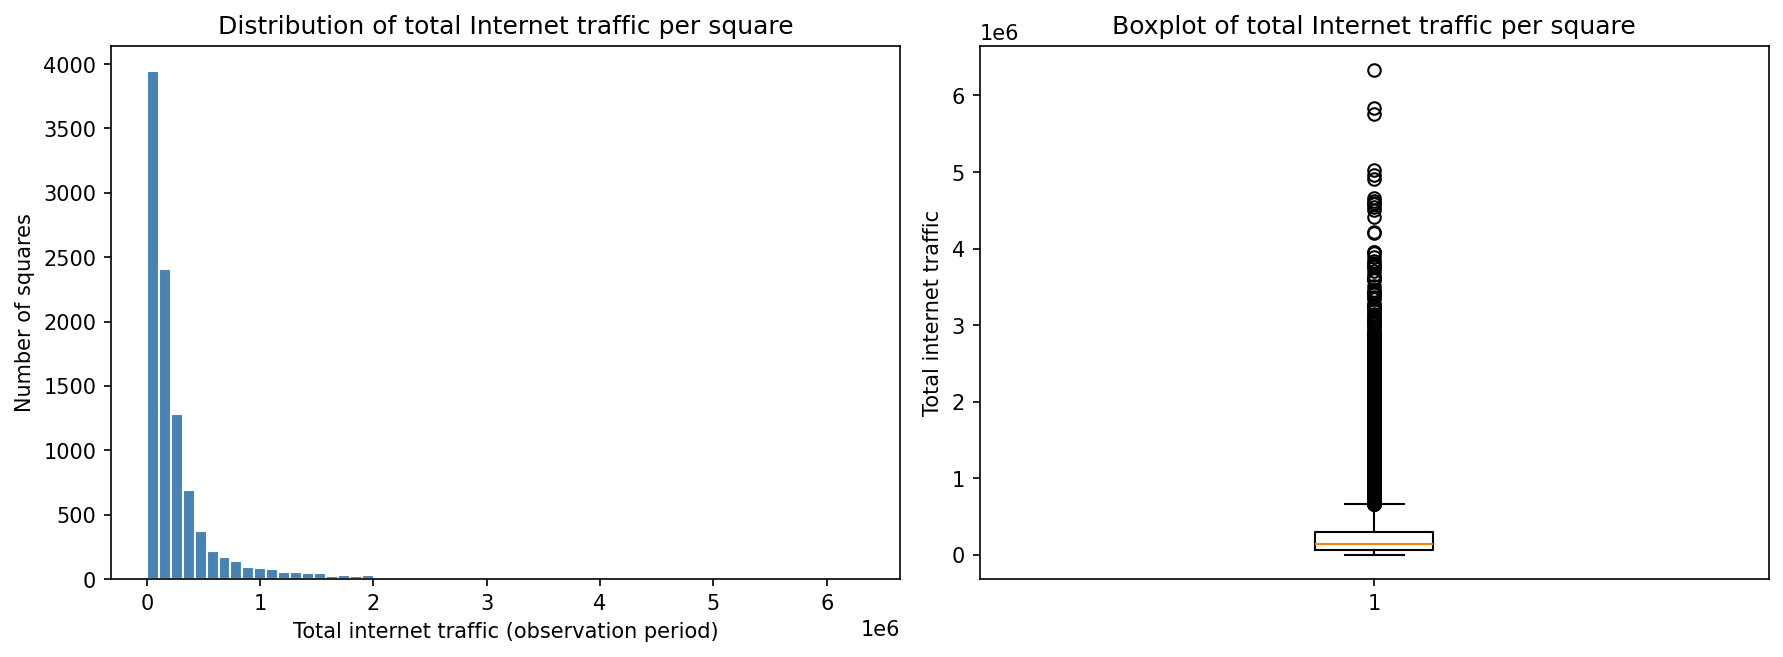

,n_squares,mean,median,std,min,max,skewness,kurtosis,p90,p99,share_top_1pct_of_total
0,10000,298268.816967,147153.475586,492294.091558,213.626533,6.329188e+06,4.241427,24.294563,679148.975977,2.609782e+06,0.11319


In [3]:
display(Image(filename="results/plots/exploratory_analysis/traffic_distribution.png"))
pd.read_csv("results/tables/data_summary.csv")

## 3. First two weeks: top-3 squares + squares 4159, 4556

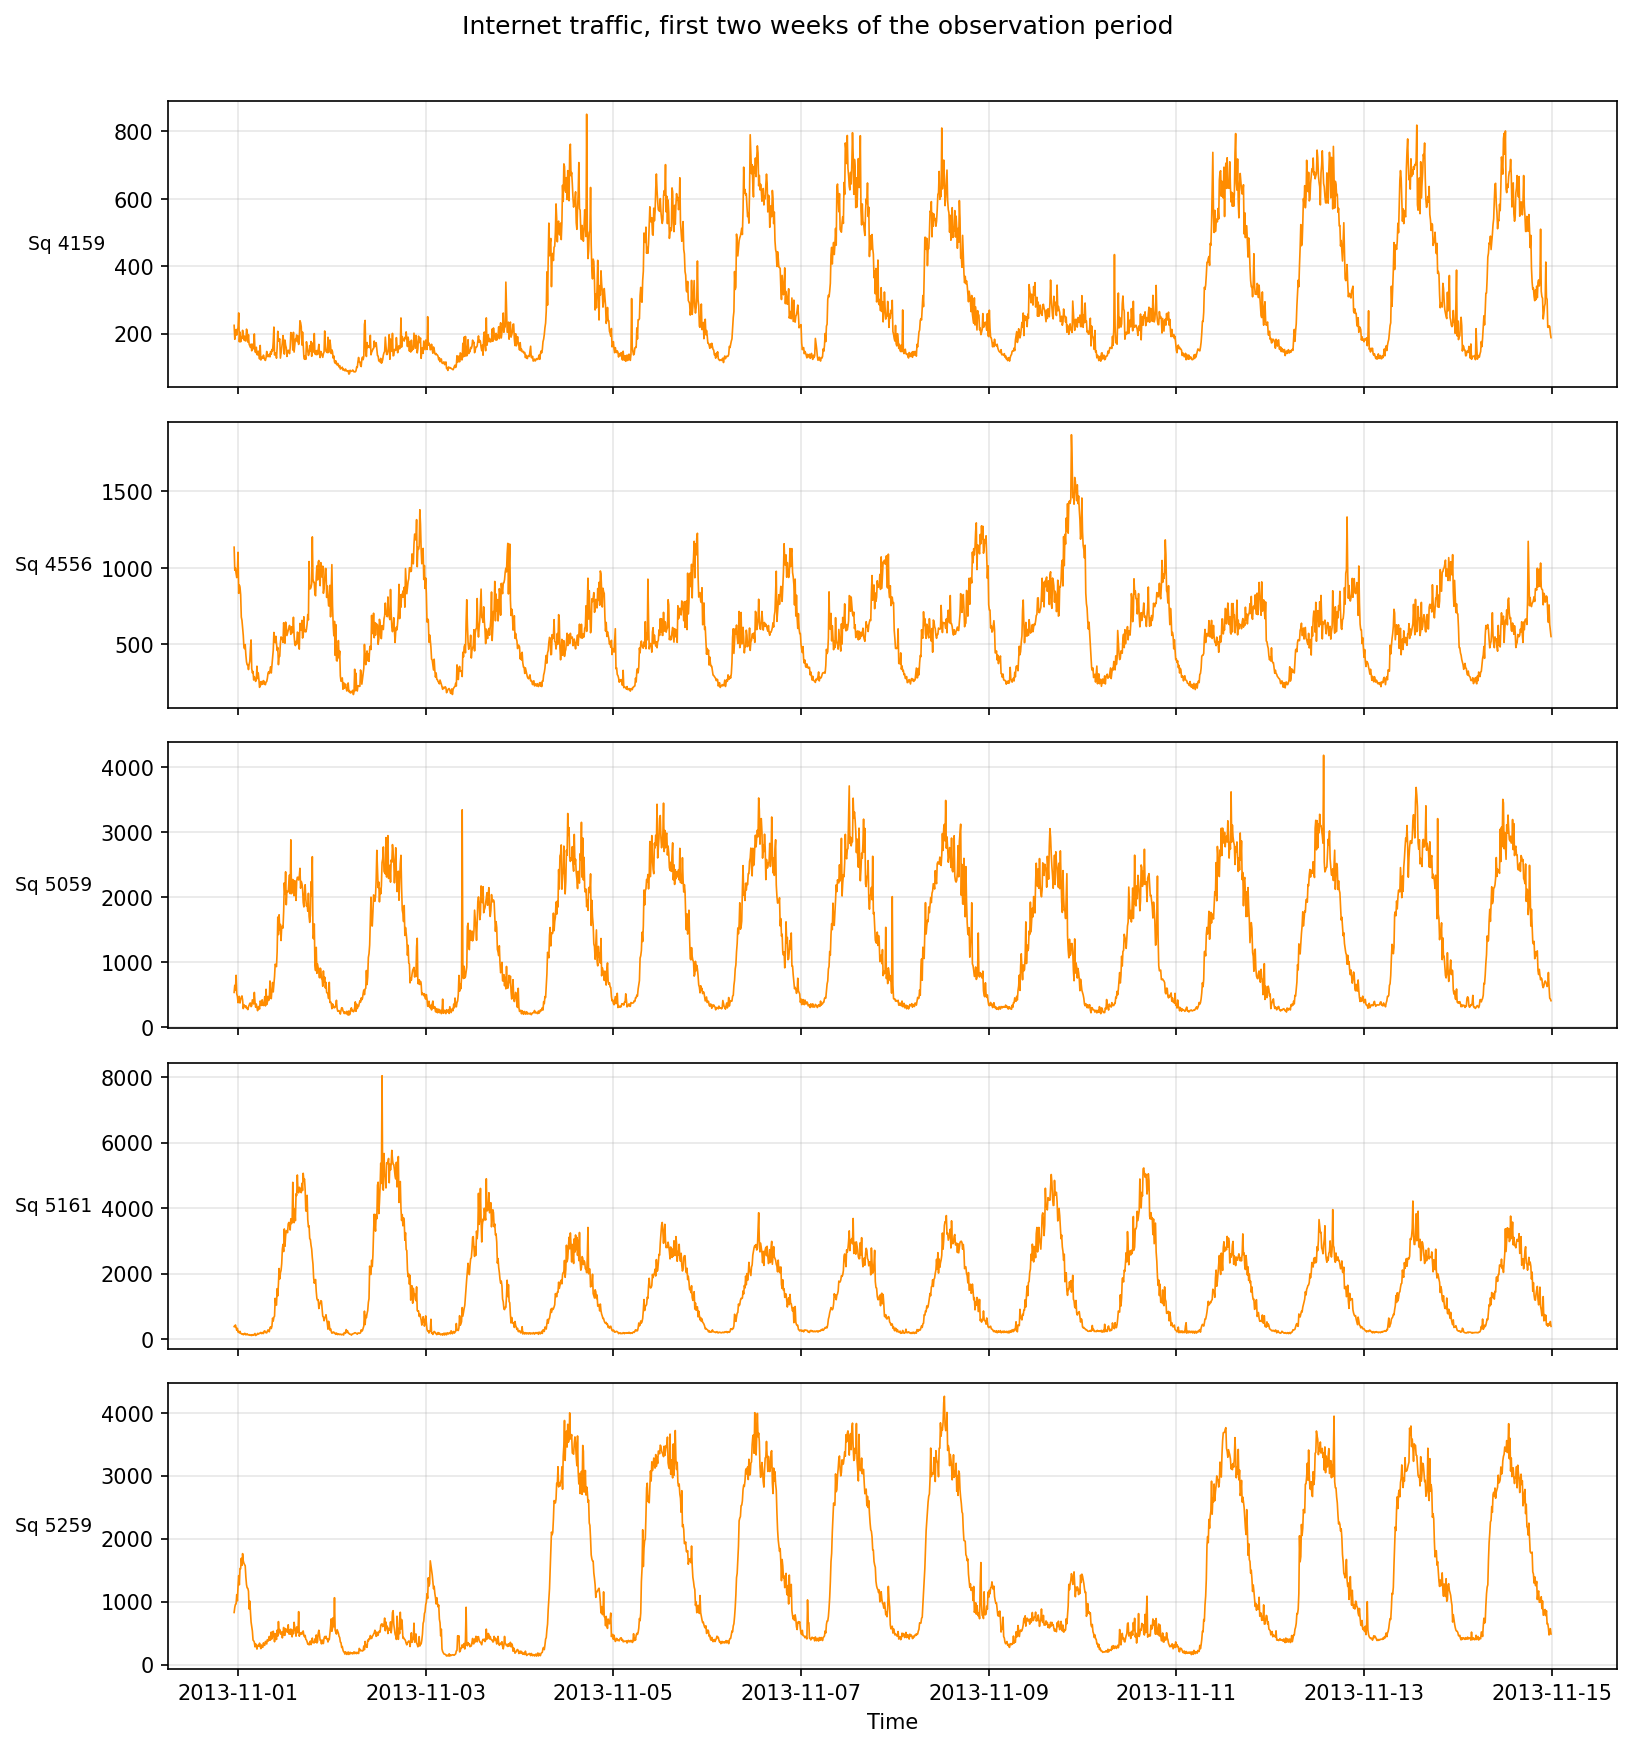

In [4]:
display(Image(filename="results/plots/exploratory_analysis/five_squares_first_two_weeks.png"))

## 4. Additional analyses on the highest-traffic square: ACF/PACF and STL decomposition

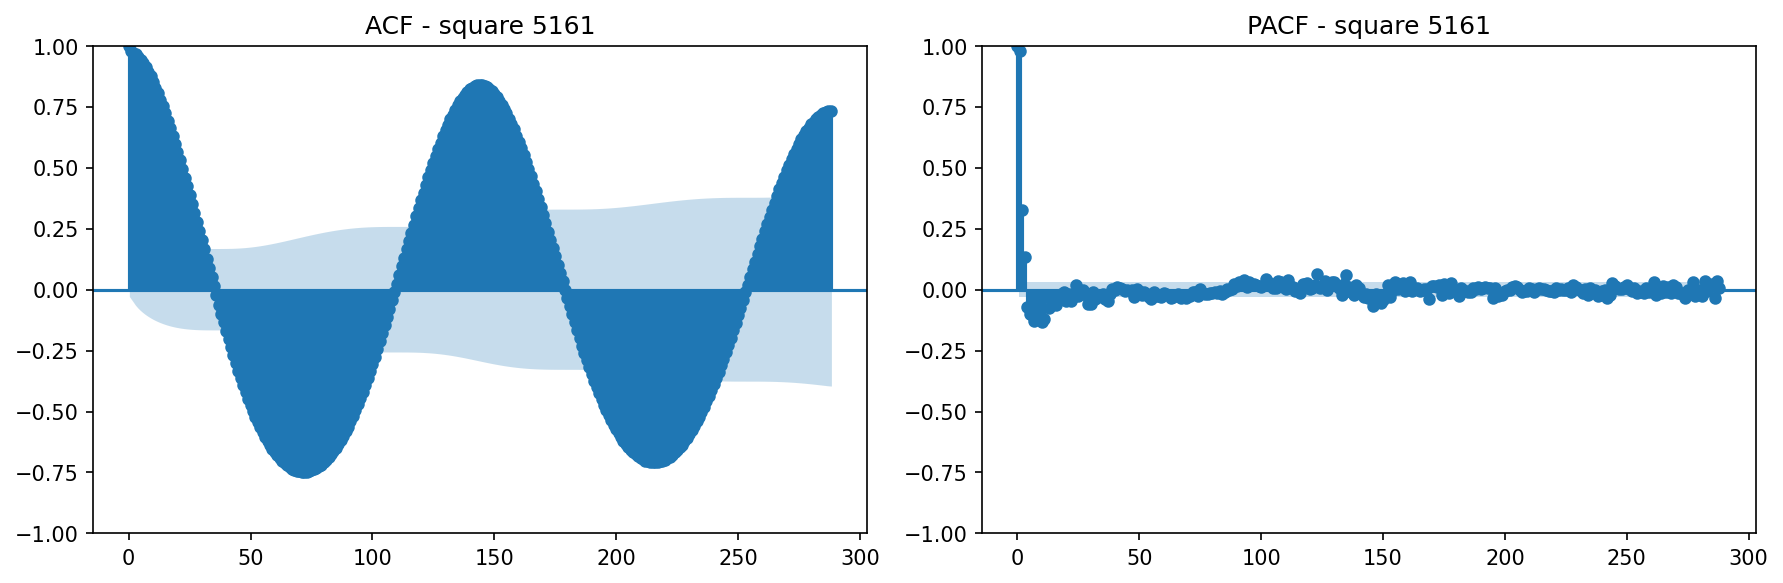

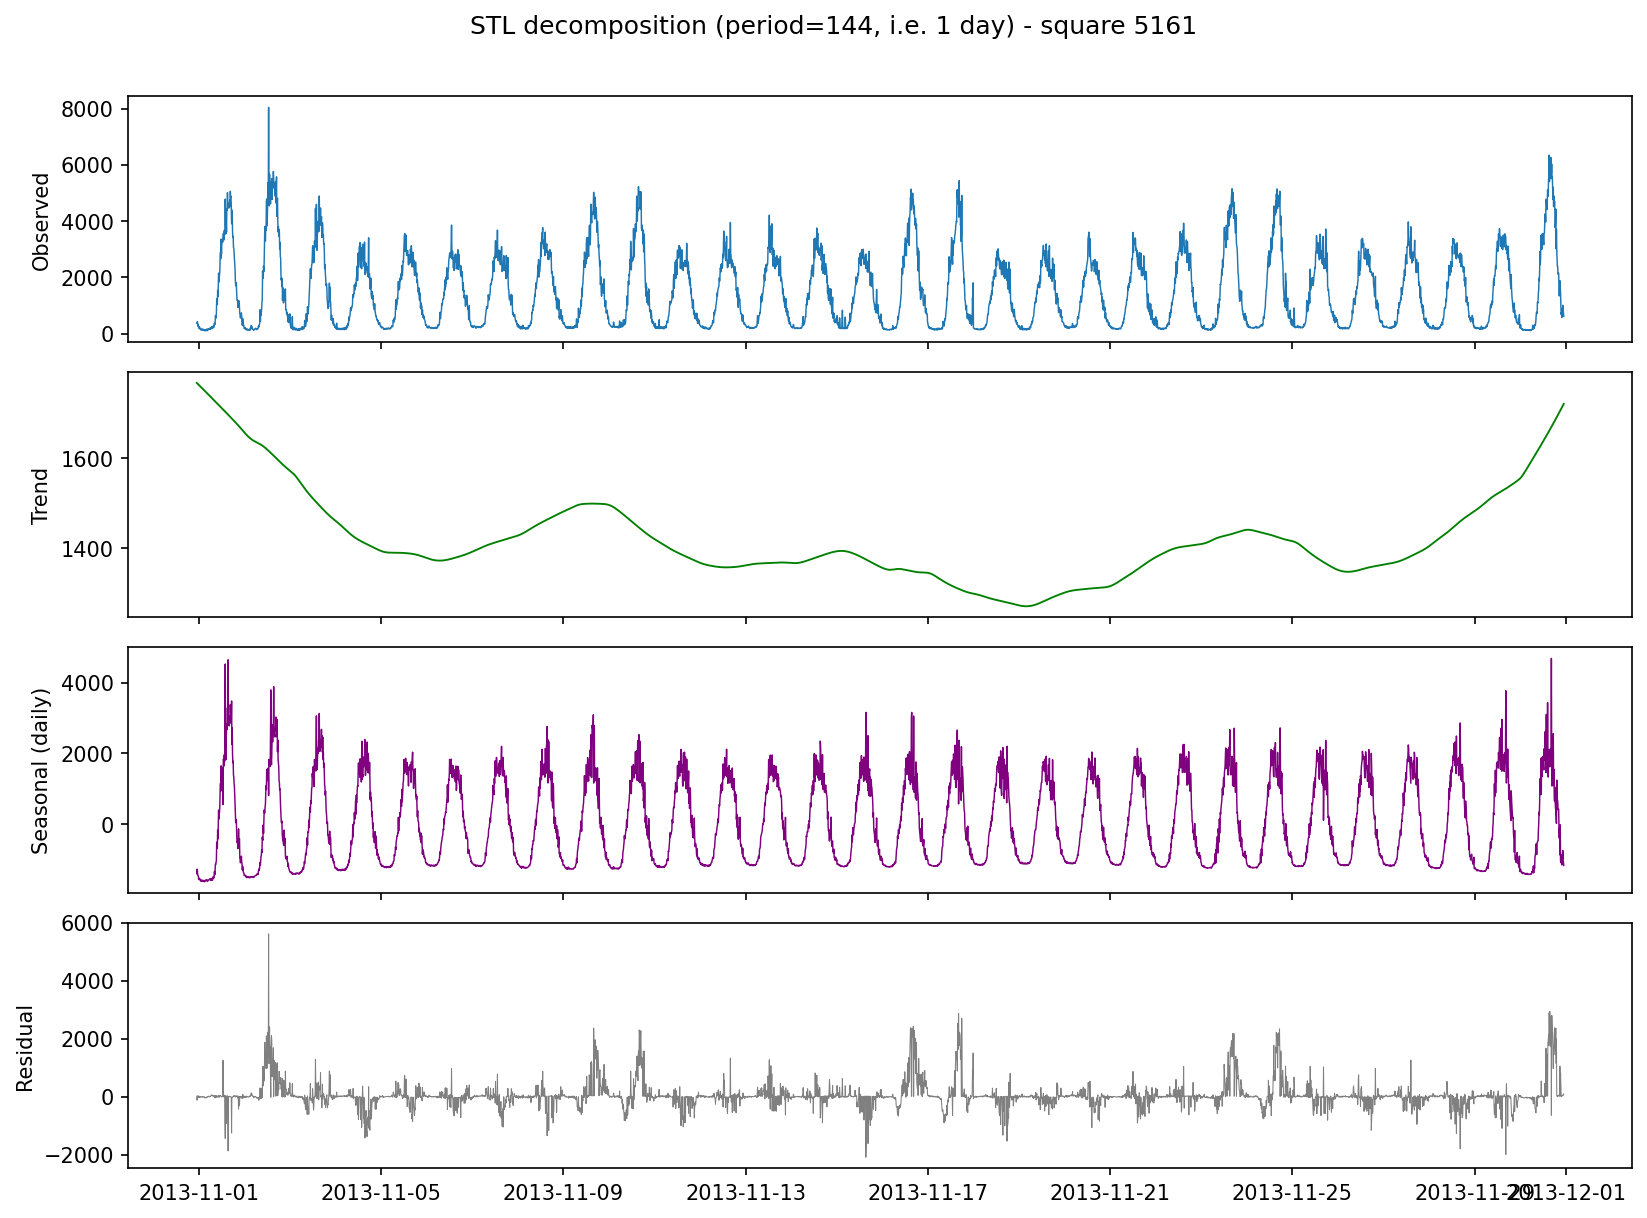

,series,adf_stat,p_value,n_lags_used,critical_5pct,stationary_at_5pct
0,level,-13.746110,1.071817e-25,31,-2.862214,True
1,first_difference,-9.787538,6.483074e-17,29,-2.862214,True


In [5]:
display(Image(filename="results/plots/exploratory_analysis/acf_pacf_top1.png"))
display(Image(filename="results/plots/time_series_decomposition/stl_decomposition_top1.png"))
pd.read_csv("results/tables/stationarity_tests.csv")